
# EDA — Catálogo de Ejercicios de ASCEND

Exploramos el catálogo procesado de 1,324 ejercicios (ya clasificado por
zona muscular funcional y dificultad, y traducido al español)



In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4.5)

# Paleta de marca de ASCEND
VERDE_PRIMARIO = "#006a20"
VERDE_MEDIO = "#20a04e"
VERDE_SUAVE = "#8ec899"
CASI_NEGRO = "#141d16"
GRIS_VERDE = "#c7d1c9"

df = pd.read_parquet("../Data/processed/exercises_catalog_spanish_version.parquet")
print(f"Catálogo: {df.shape[0]} ejercicios, {df.shape[1]} columnas")
df.head(3)


Catálogo: 1324 ejercicios, 24 columnas


,id,name,category,equipment,instructions,instruction_steps,muscle_group,secondary_muscles,target,image,gif_url,media_id,created_at,attribution,zona_muscular,name_norm,dificultad_prestada,n_secondary,es_exigente_pred,dificultad_final,dificultad_fuente,confianza_dificultad,score_llm,dificultad_llm
0,0001,3/4 sit-up,cintura/core,peso corporal,{'en': 'Lie flat on your back with your knees ...,{'en': ['Lie flat on your back with your knees...,flexores de cadera,"[hip flexors, lower back]",abdominales,images/0001-2gPfomN.jpg,videos/0001-2gPfomN.gif,2gPfomN,2026-03-18T12:31:32.854798+00:00,© Gym visual — https://gymvisual.com/,Core,3/4 sit-up,beginner,2,0,principiante,match_fdb,0.309286,18,principiante
1,0002,45° side bend,cintura/core,peso corporal,{'en': 'Stand with your feet shoulder-width ap...,{'en': ['Stand with your feet shoulder-width a...,oblicuos,[obliques],abdominales,images/0002-Hy9D21L.jpg,videos/0002-Hy9D21L.gif,Hy9D21L,2026-03-18T12:31:32.854953+00:00,© Gym visual — https://gymvisual.com/,Core,45° side bend,None,1,0,principiante,modelo+regla,0.300529,18,principiante
2,0003,air bike,cintura/core,peso corporal,{'en': 'Lie flat on your back with your hands ...,{'en': ['Lie flat on your back with your hands...,flexores de cadera,[hip flexors],abdominales,images/0003-1ZFqTDN.jpg,videos/0003-1ZFqTDN.gif,1ZFqTDN,2026-03-18T12:31:32.854977+00:00,© Gym visual — https://gymvisual.com/,Core,air bike,beginner,1,0,principiante,match_fdb,0.309286,18,principiante



## 1. ¿Cómo se reparte el catálogo entre zonas musculares?

Antes de hablar de dificultad, vale la pena ver si el catálogo está
parejo entre zonas — si alguna zona tiene muy pocos ejercicios, cualquier
filtro que combine esa zona con un equipo específico puede quedarse sin
opciones para generar rutinas.


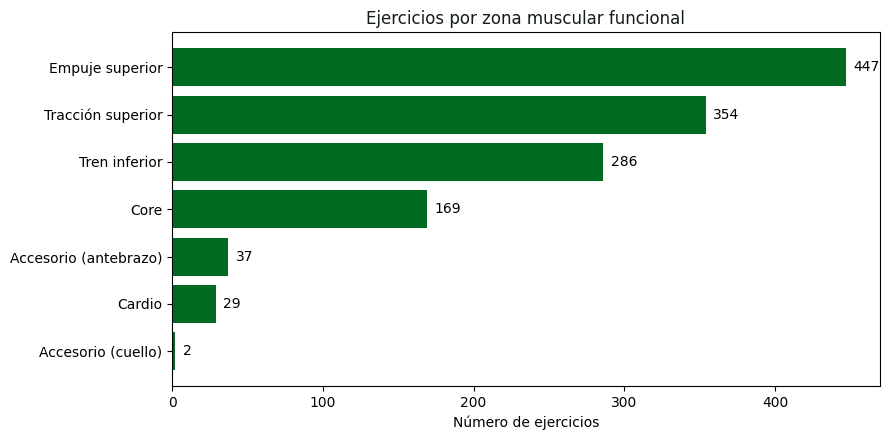

zona_muscular
Empuje superior          447
Tracción superior        354
Tren inferior            286
Core                     169
Accesorio (antebrazo)     37
Cardio                    29
Accesorio (cuello)         2
Name: count, dtype: int64


In [3]:

conteo_zonas = df["zona_muscular"].value_counts()

fig, ax = plt.subplots()
ax.barh(conteo_zonas.index[::-1], conteo_zonas.values[::-1], color=VERDE_PRIMARIO)
ax.set_xlabel("Número de ejercicios")
ax.set_title("Ejercicios por zona muscular funcional", color=CASI_NEGRO)
for i, v in enumerate(conteo_zonas.values[::-1]):
    ax.text(v + 5, i, str(v), va="center")
plt.tight_layout()
plt.show()

print(conteo_zonas)



**Lectura:** Empuje superior y Tracción superior concentran más de la
mitad del catálogo (447 + 354 de 1,324). En el otro extremo, "Accesorio (cuello)" tiene solo 2 ejercicios en todo el catálogo, cualquier filtro
que combine esa zona con un equipo poco común puede quedarse sin
resultados. Además que existe un ligero desbalance en la generación de rutinas por este hecho.



## 2. ¿Qué zona muscular tiene, en general, los ejercicios más difíciles?

Aquí es donde entra la pregunta central: ¿hay zonas musculares
sistemáticamente más exigentes que otras, o la dificultad se reparte
parecido en todas?


/tmp/ipykernel_18647/1950939483.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_por_zona, labels=orden_zonas, patch_artist=True, vert=False)


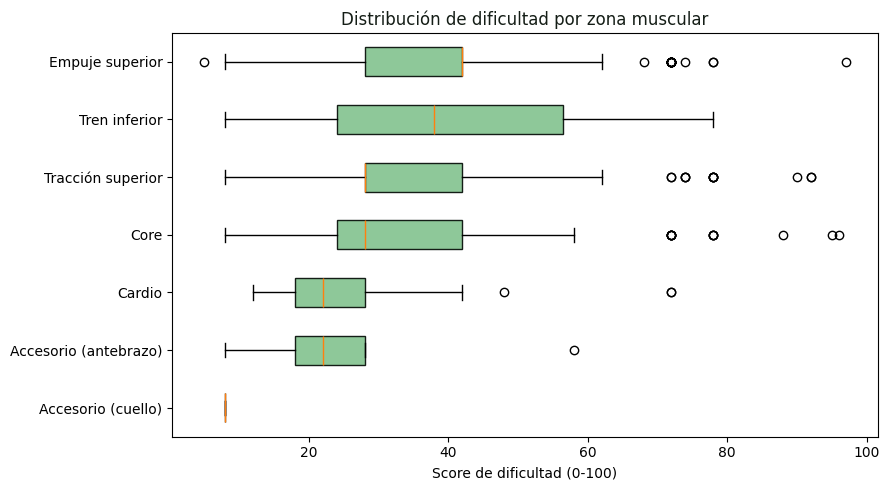

Score de dificultad promedio por zona:
zona_muscular
Empuje superior          39.3
Tren inferior            37.0
Core                     35.7
Tracción superior        34.2
Cardio                   28.3
Accesorio (antebrazo)    21.9
Accesorio (cuello)        8.0
Name: score_llm, dtype: float64


In [4]:

orden_zonas = df.groupby("zona_muscular")["score_llm"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5))
datos_por_zona = [df[df.zona_muscular == z]["score_llm"].dropna() for z in orden_zonas]
bp = ax.boxplot(datos_por_zona, labels=orden_zonas, patch_artist=True, vert=False)
for patch in bp["boxes"]:
    patch.set_facecolor(VERDE_SUAVE)
    patch.set_edgecolor(CASI_NEGRO)
ax.set_xlabel("Score de dificultad (0-100)")
ax.set_title("Distribución de dificultad por zona muscular", color=CASI_NEGRO)
plt.tight_layout()
plt.show()

print("Score de dificultad promedio por zona:")
print(df.groupby("zona_muscular")["score_llm"].mean().round(1).sort_values(ascending=False))


**Insights:**

- **Tren inferior**: variabilidad real y continua (caja ancha, sin outliers) — hay ejercicios genuinamente difíciles dentro de lo admisible, no solo casos aislados.
- **Empuje/Tracción superior y Core**: mayoría moderada (caja angosta) + outliers altos — la dificultad exigente ahí es la excepción.
- **Cardio y Accesorio (antebrazo)**: poca dispersión.
- **Accesorio (cuello)**: sin distribución — solo 2 ejercicios en el catálogo.


## 3. ¿Y en términos de las 3 categorías (principiante/intermedio/experto)?

El score continuo puede ocultar diferencias que sí se notan cuando lo
vemos como proporción de categorías completas por zona.


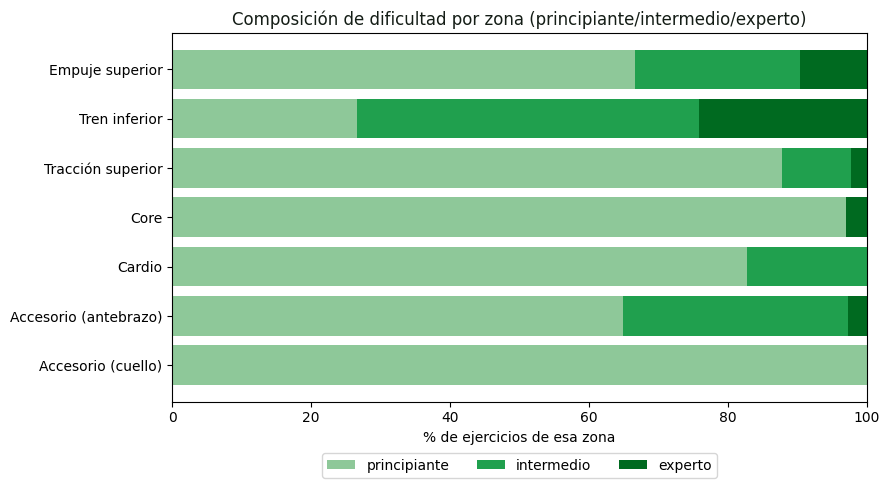

dificultad_final,principiante,intermedio,experto
zona_muscular,,,
Accesorio (cuello),100.0,0.0,0.0
Accesorio (antebrazo),64.9,32.4,2.7
Cardio,82.8,17.2,0.0
Core,97.0,0.0,3.0
Tracción superior,87.9,9.9,2.3
Tren inferior,26.6,49.3,24.1
Empuje superior,66.7,23.7,9.6


In [5]:

tabla_cruzada = pd.crosstab(df["zona_muscular"], df["dificultad_final"], normalize="index") * 100
orden_columnas = ["principiante", "intermedio", "experto"]
tabla_cruzada = tabla_cruzada[orden_columnas].loc[orden_zonas]

fig, ax = plt.subplots(figsize=(9, 5))
izquierda = np.zeros(len(tabla_cruzada))
colores = [VERDE_SUAVE, VERDE_MEDIO, VERDE_PRIMARIO]
for columna, color in zip(orden_columnas, colores):
    ax.barh(tabla_cruzada.index, tabla_cruzada[columna], left=izquierda, color=color, label=columna)
    izquierda += tabla_cruzada[columna].values

ax.set_xlabel("% de ejercicios de esa zona")
ax.set_title("Composición de dificultad por zona (principiante/intermedio/experto)", color=CASI_NEGRO)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()

tabla_cruzada.round(1)


In [6]:
# ---------------------------------------------------------------------------
# Mismos cortes que usa clasificar_tier() en producción sobre score_llm
# (30 y 50 separan los bloques naturales de la escala en 3 grupos con
# sentido práctico: fácil / moderado / exigente).
# ---------------------------------------------------------------------------
LIMITE_SUPERIOR_POR_TIER = {"principiante": 30, "intermedio": 50, "experto": 100}


def clasificar_tier(score_llm: float) -> str:
    if score_llm <= LIMITE_SUPERIOR_POR_TIER["principiante"]:
        return "principiante"
    if score_llm <= LIMITE_SUPERIOR_POR_TIER["intermedio"]:
        return "intermedio"
    return "experto"


df["dificultad_llm_tier"] = df["score_llm"].map(clasificar_tier)

# One-hot: una columna 0/1 por tier, sufijadas con _llm para distinguirlas
# de dificultad_final (el modelo estadístico viejo).
dummies_llm = pd.get_dummies(df["dificultad_llm_tier"]).add_suffix("_llm")
df = pd.concat([df, dummies_llm], axis=1)

## ¿Por qué no usamos `dificultad_final` (el modelo Random Forest)?

dificultad_final viene del modelo estadístico que entrenamos con muy
pocos datos etiquetados de forma confiable (~177 de 1,324, el match
contra Free Exercise DB) y una regla de equipo para dividir
intermedio/experto. El problema no es solo el tamaño de muestra — es
que esa clasificación es dicotomica.

Esa diferencia importa en la práctica: un ejercicio con equipo pesado
(barra, kettlebell, máquina smith) puede quedar justo por debajo del
corte de probabilidad del Random Forest, y etiquetado
"principiante", cuando en realidad es avanzado.

El resultado: el generador de rutinas confiaría en una
etiqueta que categoriza ejercicios genuinamente difíciles como
accesibles, sesgando las recomendaciones hacia arriba sin que el
usuario lo note. Por eso, en producción, `dificultad_final` se ignora
por completo y todo se calcula sobre `score_llm`.

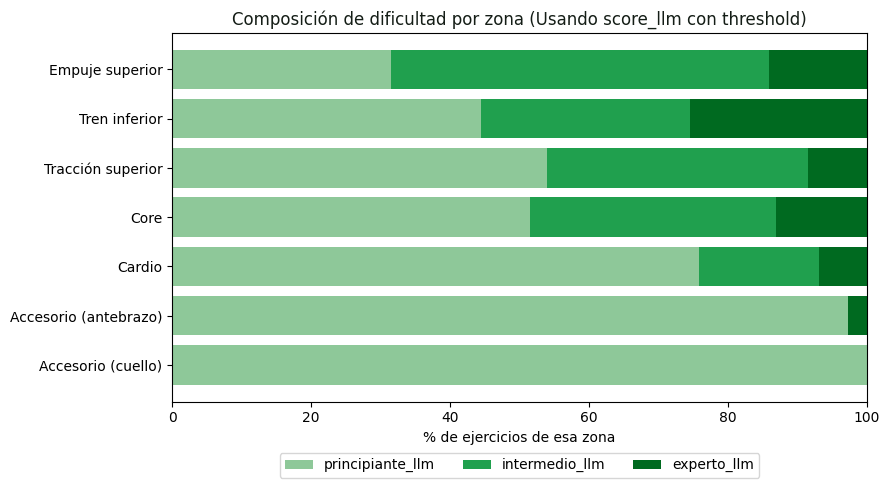

,principiante_llm,intermedio_llm,experto_llm
zona_muscular,,,
Accesorio (cuello),100.0,0.0,0.0
Accesorio (antebrazo),97.3,0.0,2.7
Cardio,75.9,17.2,6.9
Core,51.5,35.5,13.0
Tracción superior,54.0,37.6,8.5
Tren inferior,44.4,30.1,25.5
Empuje superior,31.5,54.4,14.1


In [7]:
# ---------------------------------------------------------------------------
# Misma gráfica de antes, pero agregando por zona el % de cada columna _llm
# en vez del crosstab de dificultad_final.
# ---------------------------------------------------------------------------
tabla_cruzada_llm = (
    df.groupby("zona_muscular")[["principiante_llm", "intermedio_llm", "experto_llm"]]
    .mean() * 100
)
orden_columnas_llm = ["principiante_llm", "intermedio_llm", "experto_llm"]
tabla_cruzada_llm = tabla_cruzada_llm[orden_columnas_llm].loc[orden_zonas]

fig, ax = plt.subplots(figsize=(9, 5))
izquierda = np.zeros(len(tabla_cruzada_llm))
colores = [VERDE_SUAVE, VERDE_MEDIO, VERDE_PRIMARIO]
for columna, color in zip(orden_columnas_llm, colores):
    ax.barh(tabla_cruzada_llm.index, tabla_cruzada_llm[columna], left=izquierda, color=color, label=columna)
    izquierda += tabla_cruzada_llm[columna].values

ax.set_xlabel("% de ejercicios de esa zona")
ax.set_title("Composición de dificultad por zona (Usando score_llm con threshold)", color=CASI_NEGRO)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()

tabla_cruzada_llm.round(1)

**Insights:**

- **Core es el caso más revelador:** aquí solo ~52% cae en "principiante", contra el ~97% que mostraba `dificultad_final` 
- **Tren inferior sigue siendo la más exigente**, ahora con evidencia más fina: ~25% experto, la proporción más alta de todas las zonas — consistente con el boxplot inicial.
- **Empuje superior** también sube su exigencia real: solo ~32% principiante, con un bloque de experto notable (~15%) — más difícil de lo que sugería la clasificación anterior.

Al pasar de `dificultad_final` a `score_llm`, casi todas las zonas "suben" en dificultad percibida, casi no bajan. 

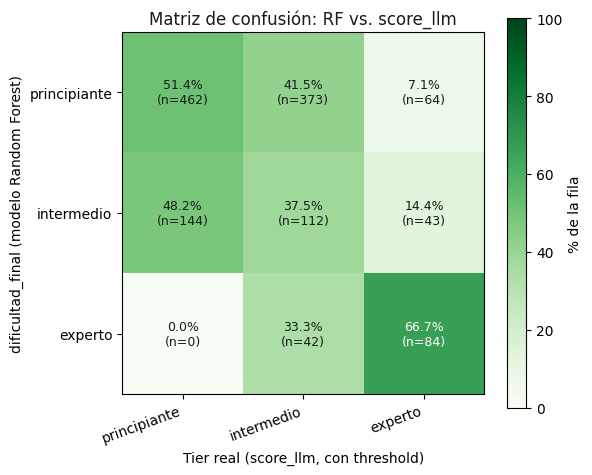

dificultad_llm_tier,principiante,intermedio,experto
dificultad_final,,,
principiante,462,373,64
intermedio,144,112,43
experto,0,42,84


In [13]:
orden_dificultad = ["principiante", "intermedio", "experto"]

matriz_confusion = pd.crosstab(df["dificultad_final"], df["dificultad_llm_tier"])
matriz_confusion = matriz_confusion.reindex(index=orden_dificultad, columns=orden_dificultad, fill_value=0)

matriz_confusion_pct = (matriz_confusion.div(matriz_confusion.sum(axis=1), axis=0) * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz_confusion_pct.values, cmap="Greens", vmin=0, vmax=100)
ax.set_xticks(range(3)); ax.set_xticklabels(orden_dificultad, rotation=20, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels(orden_dificultad)
ax.set_xlabel("Tier real (score_llm, con threshold)")
ax.set_ylabel("dificultad_final (modelo Random Forest)")
ax.set_title("Matriz de confusión: RF vs. score_llm", color=CASI_NEGRO)

for i in range(3):
    for j in range(3):
        pct = matriz_confusion_pct.iloc[i, j]
        n = matriz_confusion.iloc[i, j]
        color_texto = "white" if pct > 55 else CASI_NEGRO
        ax.text(j, i, f"{pct:.1f}%\n(n={n})", ha="center", va="center", color=color_texto, fontsize=9)

fig.colorbar(im, ax=ax, label="% de la fila")
plt.tight_layout()
plt.show()

matriz_confusion

**Insights:**

- **La fila "principiante" es la más preocupante:** solo 51.4% coincide con el score_llm, el otro 48.6% son ejercicios que el RF llamó "accesibles" pero que en realidad son intermedios (41.5%) o expertos. No clasifica bien.

- **La fila "intermedio" es aún peor:** 48.2% de lo que el RF llama "intermedio" en realidad es "principiante" — el RF está etiquetando ejercicios fáciles como moderados casi la mitad de las veces.

- **El error es unidireccional, confirmado con estos números:** la fila "experto" tiene 0.0% en la columna "principiante" — el RF nunca se equivoca en esa dirección. Todo el error empuja hacia ABAJO (llamar fácil a algo difícil), nunca hacia arriba.

**Conclusión:** de las 3 filas, ninguna supera 67% de acierto, es una fuente de etiqueta poco confiable en las 3 categorías, con el riesgo más alto concentrado en subestimar dificultad real.


## 4. ¿Qué equipo está asociado a ejercicios más difíciles?

Filtramos a equipos con al menos 10 ejercicios en el catálogo


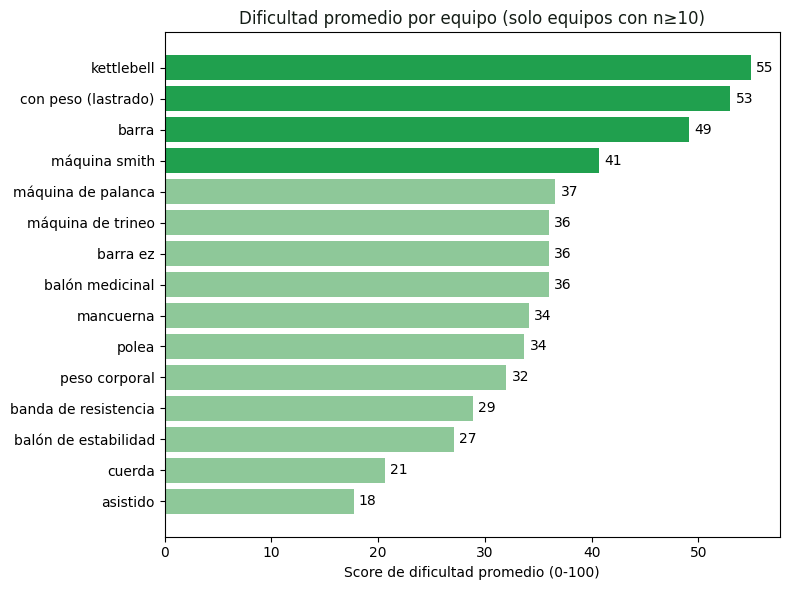

Equipos excluidos por muestra insuficiente (n<10): ['balón bosu', 'barra hexagonal', 'barra olímpica', 'bicicleta estática', 'elíptica', 'ergómetro de tren superior', 'escaladora', 'llanta', 'máquina hammer', 'máquina skierg', 'rodillo', 'rueda abdominal']


In [8]:

conteo_equipo = df["equipment"].value_counts()
equipos_con_muestra_suficiente = conteo_equipo[conteo_equipo >= 10].index

score_por_equipo = (
    df[df.equipment.isin(equipos_con_muestra_suficiente)]
    .groupby("equipment")["score_llm"]
    .mean()
    .round(1)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
colores_barra = [VERDE_PRIMARIO if v >= 55 else (VERDE_MEDIO if v >= 40 else VERDE_SUAVE) for v in score_por_equipo.values]
ax.barh(score_por_equipo.index, score_por_equipo.values, color=colores_barra)
ax.set_xlabel("Score de dificultad promedio (0-100)")
ax.set_title("Dificultad promedio por equipo (solo equipos con n≥10)", color=CASI_NEGRO)
for i, v in enumerate(score_por_equipo.values):
    ax.text(v + 0.5, i, f"{v:.0f}", va="center")
plt.tight_layout()
plt.show()

print(f"Equipos excluidos por muestra insuficiente (n<10): {sorted(conteo_equipo[conteo_equipo < 10].index.tolist())}")



Kettlebell (81.5) y barra (60.8) encabezan la lista.
Consistente con que ambos suelen usarse en movimientos compuestos de
alta exigencia técnica. En el otro extremo, polea (18.8) y máquina de
palanca (27.3) son las más accesibles, tiene sentido, las máquinas
guiadas reducen el componente de estabilización/coordinación que es
justo lo que más pesa en la rúbrica de dificultad.



## 5. ¿Más músculos secundarios involucrados = más difícil?

Cuántos músculos secundarios activa un ejercicio, además
del principal. La hipótesis es que ejercicios más compuestos deberían ser más exigentes.


Correlación n_secondary vs score de dificultad: 0.383


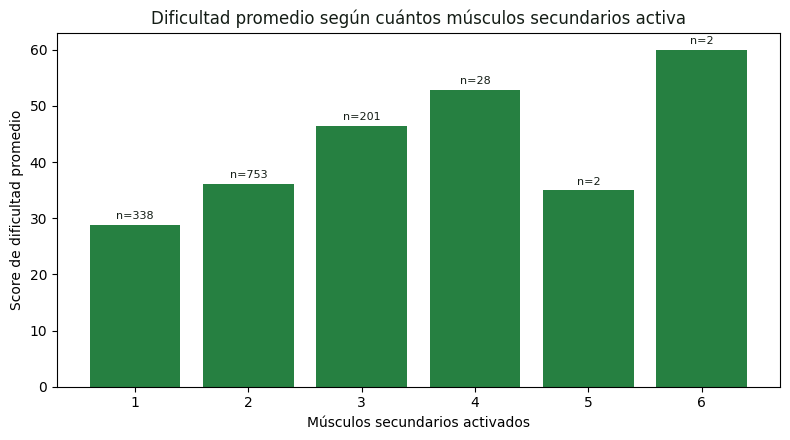

In [9]:

correlacion = df["n_secondary"].corr(df["score_llm"])
print(f"Correlación n_secondary vs score de dificultad: {correlacion:.3f}")

conteo_por_n = df["n_secondary"].value_counts().sort_index()
promedio_por_n = df.groupby("n_secondary")["score_llm"].mean().round(1)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(promedio_por_n.index, promedio_por_n.values, color=VERDE_PRIMARIO, alpha=0.85)
ax1.set_xlabel("Músculos secundarios activados")
ax1.set_ylabel("Score de dificultad promedio")
ax1.set_title("Dificultad promedio según cuántos músculos secundarios activa", color=CASI_NEGRO)
for x, y, n in zip(promedio_por_n.index, promedio_por_n.values, conteo_por_n.reindex(promedio_por_n.index)):
    ax1.text(x, y + 1, f"n={n}", ha="center", fontsize=8, color=CASI_NEGRO)
plt.tight_layout()
plt.show()



**Lectura:** correlación positiva moderada (~0.34) — confirma la
hipótesis en la dirección esperada, pero no es un predictor fuerte por
sí solo. La tendencia clara está
en el rango 1 a 4, donde sí hay suficientes ejercicios para confiar en
el promedio.



## 6. ¿Dónde está la mayor concentración de dificultad?


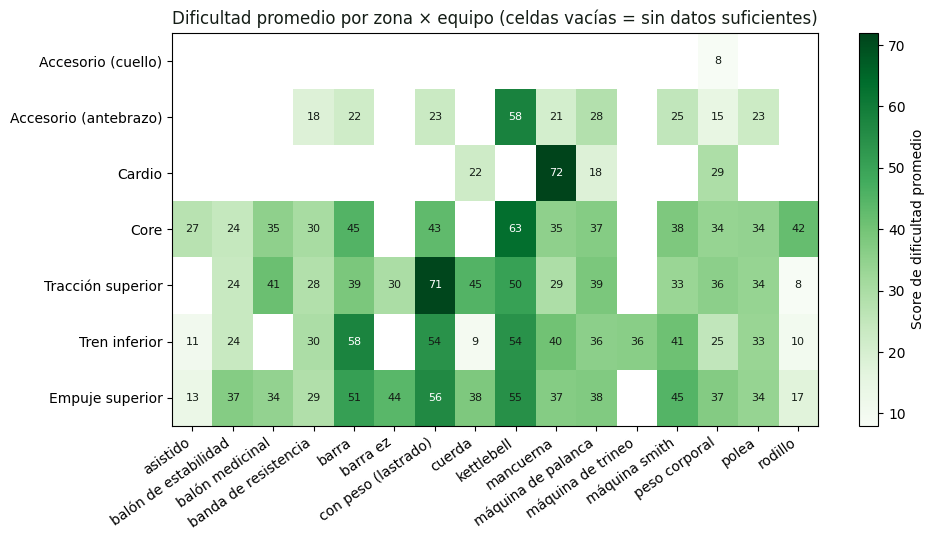

In [10]:

equipos_top = conteo_equipo[conteo_equipo >= 5].index  # umbral un poco más estricto para el cruce (menos celdas, más confiables)
pivote = df[df.equipment.isin(equipos_top)].pivot_table(
    index="zona_muscular", columns="equipment", values="score_llm", aggfunc="mean"
)
pivote = pivote.loc[orden_zonas]

fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(pivote.values, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(pivote.columns)))
ax.set_xticklabels(pivote.columns, rotation=35, ha="right")
ax.set_yticks(range(len(pivote.index)))
ax.set_yticklabels(pivote.index)

for i in range(pivote.shape[0]):
    for j in range(pivote.shape[1]):
        valor = pivote.values[i, j]
        if not np.isnan(valor):
            color_texto = "white" if valor > 55 else CASI_NEGRO
            ax.text(j, i, f"{valor:.0f}", ha="center", va="center", color=color_texto, fontsize=8)

ax.set_title("Dificultad promedio por zona × equipo (celdas vacías = sin datos suficientes)", color=CASI_NEGRO)
fig.colorbar(im, ax=ax, label="Score de dificultad promedio")
plt.tight_layout()
plt.show()


**Insights del cruce zona × equipo:**

- Kettlebell y "con peso (lastrado)" son consistentemente las celdas más oscuras en casi cualquier zona donde aparecen.

- **Polea y máquina de palanca hacen lo opuesto en todas las zonas:** El patrón de equipo "accesible" también es transversal, no exclusivo de una zona en particular.

- **El valor más alto del mapa (72, en Cardio)** Justamente se trata de ejercicios de alto rendimiento de cardio junto con mancuernas, lo cual añade dificultad adicional.

**Conclusión:** la dificultad no depende solo de "qué zona" ni solo de "qué equipo" por separado — el cruce confirma que ambos factores se combinan de forma consistente, y que el catálogo tiene huecos reales de cobertura que el generador de rutinas debe manejar (por ejemplo, cayendo a un equipo alternativo cuando la combinación pedida no tiene suficientes opciones).